In [ ]:
!pip install alerce

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.8 MB/s eta 0:00:00


In [24]:
# Script for searching optical data on ZTF using the ALeRCE cone search API
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from alerce.core import Alerce

In [ ]:
client = Alerce()
sco_x1 = client.query_objects(
    survey="ztf",
    ra=244.9794039,
    dec=-15.6403666,
    radius=5
)

In [ ]:
sco_x1

,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,...,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr
0,ZTF19aaetdak,727,1180,58298.230799,60351.525000,True,False,590,-0.075,-0.009747,...,60407.483889,1900.944838,244.979396,-15.640345,0.012214,0.011761,None,None,None,1.1.6
1,ZTF22aaeeezz,1127,1687,58247.417523,60834.396157,False,False,80,NaN,NaN,...,60834.396157,1160.978264,244.979433,-15.640379,0.008342,0.008033,None,None,None,27.5.6
2,ZTF19aabzuib,1437,2114,58247.417523,61197.420000,True,False,1060,NaN,NaN,...,61197.420000,2690.880949,244.979404,-15.640367,0.001529,0.001472,None,None,None,27.5.7a32.dev1


In [ ]:
# Get light curve
lc = client.query_lightcurve("ZTF19aaetdak", survey="ztf")

In [ ]:
lc

{'detections': [{'tid': 'ztf',
   'mjd': 58993.27082179999,
   'candid': '1239270824515010008',
   'fid': 1,
   'pid': 1239270824515,
   'diffmaglim': 20.1697,
   'isdiffpos': -1,
   'nid': 1239,
   'distnr': 0.310104,
   'magpsf': 14.8786,
   'magpsf_corr': 12.678429,
   'magpsf_corr_ext': None,
   'magap': 15.0155,
   'magap_corr': None,
   'sigmapsf': 0.070404,
   'sigmapsf_corr': 100.0,
   'sigmapsf_corr_ext': 0.009279588,
   'sigmagap': 0.009,
   'sigmagap_corr': None,
   'ra': 244.9794955,
   'dec': -15.6402485,
   'rb': 0.572857,
   'rbversion': 't17_f5_c3',
   'drb': None,
   'magapbig': 15.0018,
   'sigmagapbig': 0.0092,
   'rfid': None,
   'has_stamp': False,
   'corrected': True,
   'dubious': False,
   'candid_alert': None,
   'step_id_corr': 'bulk_1.0.0',
   'phase': 0.0,
   'parent_candid': 1266218104515015023},
  {'tid': 'ztf',
   'mjd': 58993.29561340017,
   'candid': '1239295614515010059',
   'fid': 2,
   'pid': 1239295614515,
   'diffmaglim': 20.236,
   'isdiffpos': -

In [ ]:
detections_df = pd.DataFrame(lc['detections'])
display(detections_df.head())

,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,...,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,candid_alert,step_id_corr,phase,parent_candid
0,ztf,58993.270822,1239270824515010008,1,1239270824515,20.1697,-1,1239,0.310104,14.8786,...,15.0018,0.0092,NaN,False,True,False,None,bulk_1.0.0,0.0,1.266218e+18
1,ztf,58993.295613,1239295614515010059,2,1239295614515,20.2360,-1,1239,0.148525,14.6170,...,14.6385,0.0065,NaN,False,True,False,None,bulk_1.0.0,0.0,1.266218e+18
2,ztf,58996.191435,1242191433215015006,1,1242191433215,19.7884,1,1242,0.426678,14.0512,...,13.8691,0.0045,NaN,False,True,False,None,bulk_1.0.0,0.0,1.266218e+18
3,ztf,59011.314907,1257314903215010011,2,1257314903215,19.8611,-1,1257,0.365205,14.0986,...,14.1031,0.0043,NaN,False,True,False,None,bulk_1.0.0,0.0,1.266218e+18
4,ztf,59011.335301,1257335304515010078,2,1257335304515,19.6630,-1,1257,0.305905,14.0731,...,14.1359,0.0047,NaN,False,True,False,None,bulk_1.0.0,0.0,1.266218e+18


The `fid` column represents the filter band. For ZTF, `fid=1` is g-band and `fid=2` is r-band. Let's plot these separately.

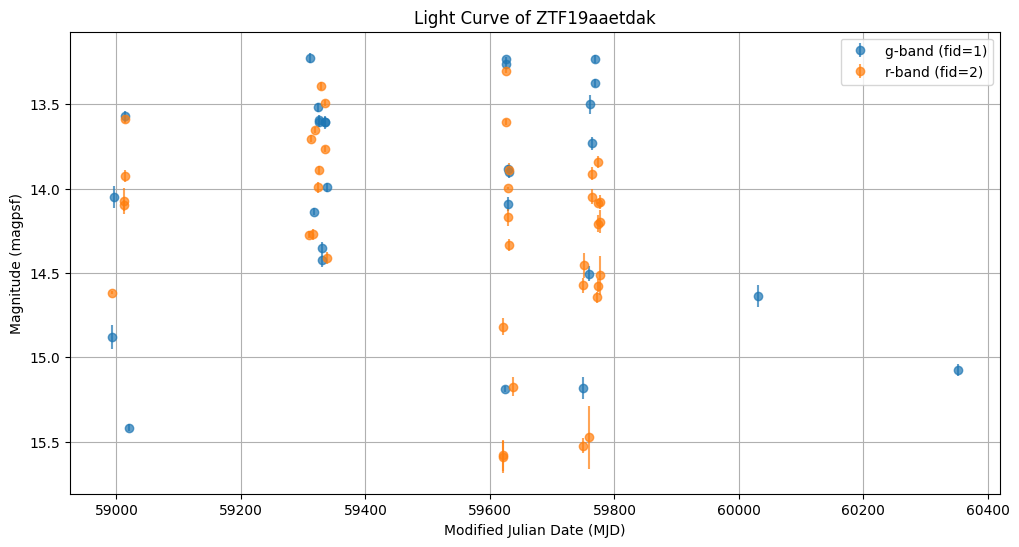

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Filter for g-band (fid=1)
g_band = detections_df[detections_df['fid'] == 1]
ax.errorbar(g_band['mjd'], g_band['magpsf'], yerr=g_band['sigmapsf'], fmt='o', label='g-band (fid=1)', alpha=0.7)

# Filter for r-band (fid=2)
r_band = detections_df[detections_df['fid'] == 2]
ax.errorbar(r_band['mjd'], r_band['magpsf'], yerr=r_band['sigmapsf'], fmt='o', label='r-band (fid=2)', alpha=0.7)

ax.set_xlabel('Modified Julian Date (MJD)')
ax.set_ylabel('Magnitude (magpsf)')
ax.set_title('Light Curve of ZTF19aaetdak')
ax.invert_yaxis() # Magnitudes are usually plotted with brighter objects (smaller magnitudes) at the top
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
# Cross matching catalogs for a single source
cross_match = client.catshtm_crossmatch(244.9794039, -15.6403666, 5, catalog_name='all', format='pandas')
cross_match_df = pd.DataFrame(cross_match)
cross_match_df

,2MASS,GAIA/DR1,GAIA/DR2,GALEX,APASS,NVSS,SkyMapper,UCAC4,WISE,AAVSO_VSX,unWISE
A,NaN,NaN,NaN,NaN,NaN,NaN,2.55,NaN,NaN,NaN,NaN
A_G,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B,NaN,NaN,NaN,NaN,12.838,NaN,2.42,NaN,NaN,NaN,NaN
BV,NaN,NaN,NaN,NaN,0.197,NaN,NaN,NaN,NaN,NaN,NaN
BVerr,NaN,NaN,NaN,NaN,0.489,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
vPSF,NaN,NaN,NaN,NaN,NaN,NaN,12.921,NaN,NaN,NaN,NaN
vPetro,NaN,NaN,NaN,NaN,NaN,NaN,12.854,NaN,NaN,NaN,NaN
zErrPSF,NaN,NaN,NaN,NaN,NaN,NaN,0.122,NaN,NaN,NaN,NaN
zPSF,NaN,NaN,NaN,NaN,NaN,NaN,12.834,NaN,NaN,NaN,NaN


In [26]:
# Cross matching entire SWIFT catalogs using conesearch
swift_cat = pd.read_csv("Swift_BAT_Transient_Sources.csv")

# Convert RA and Dec to numeric, coercing errors to NaN
swift_cat['RA J2000 Degs'] = pd.to_numeric(swift_cat['RA J2000 Degs'], errors='coerce')
swift_cat['Dec J2000 Degs'] = pd.to_numeric(swift_cat['Dec J2000 Degs'], errors='coerce')

# Drop rows where RA or Dec are NaN after conversion
swift_cat = swift_cat.dropna(subset=['RA J2000 Degs', 'Dec J2000 Degs']).reset_index(drop=True)

display(swift_cat.head())

,Row,Source Name,RA J2000 Degs,Dec J2000 Degs,Alternate Name,Source Type,Today#,Yesterday#,Tenday#,Mean*,Peak*,Days*,Last Day*
0,1.0,QSO B0003-066,1.55789,-6.39315,NRAO 005,BL Lac,-,-,-,-,-,-,-
1,2.0,PSR J0007+7303,1.75600,73.05200,0FGL J0007.4+7303,Pulsar,-,-,-,0,62,4,58107 ( 2074)
2,3.0,QSO B0007+107,2.62919,10.97490,Mrk 1501,Sy1,-,-,-,0,0,1,1 ( 0)
3,4.0,QSO B0016+73,4.94078,73.45830,NaN,Quasar,-,-,-,0,0,3,1 ( 0)
4,5.0,IGR J00234+6141,5.74000,61.68500,V1033 Cas,CV,-,-,-,0,0,5,1 ( 0)


In [34]:
RA = swift_cat['RA J2000 Degs']
DEC = swift_cat['Dec J2000 Degs']
all_cross_matches = [] # To store results from each source

# Rate limiting — with 1,057 sources, you may want to add a small time.sleep(0.2) inside the loop to avoid
# hitting the ALeRCE API rate limit
import time

for source_name, ra, dec in zip(swift_cat["Source Name"], RA, DEC):
    try:
        # Reduced radius to prevent API overload for a large number of queries
        cross_match_raw = client.catshtm_crossmatch(ra, dec, 5, catalog_name='all', format='pandas')

        cross_match_df = pd.DataFrame() # Initialize as empty DataFrame

        if cross_match_raw is not None:
            # Convert the raw result (which might be a dict) to a DataFrame
            try:
                cross_match_df = pd.DataFrame(cross_match_raw)
            except ValueError as ve:
                print(f"Warning: Could not convert cross_match_raw to DataFrame for source {source_name}: {ve})")
                # If conversion fails, cross_match_df remains empty

        if not cross_match_df.empty:
            # Add a column for the original source name for traceability
            cross_match_df['original_source_name'] = source_name
            all_cross_matches.append(cross_match_df)
    except Exception as e: # Catch a general exception since APIError is not directly importable
        print(f"An error occurred for source {source_name} (RA: {ra}, Dec: {dec}): {e})")
        # Continue to the next source even if one fails
        continue
    time.sleep(0.2)

# Concatenate all results into a single DataFrame
if all_cross_matches:
    combined_cross_matches_df = pd.concat(all_cross_matches, ignore_index=True)
    print("Combined Cross-Matches Head:")
    display(combined_cross_matches_df.head())
    print(f"Total cross-matches found: {len(combined_cross_matches_df)}")
else:
    print("No cross-matches found or all queries resulted in an error.")

An error occurred for source DH Leo (RA: 150.007, Dec: 24.5528): {'Error code': 500, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'})


Combined Cross-Matches Head:


,FIRST,2MASS,DECaLS,GAIA/DR1,GAIA/DR2,NEDz,SDSSoffset,NVSS,SkyMapper,WISE,...,SAGE,SpecSDSS,UKIDSS,PTFpc,Simbad_PM200,ROSATfsc,VISTAviking,VSTkids,CRTS,IRACgc
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.28,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.97,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.98,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-6.3932,-6.393204,-6.393148,-6.393149,-6.393149,-6.39315,NaN,-6.393111,-6.393127,-6.393102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Total cross-matches found: 123428


In [36]:
all_cross_matches[0]

,FIRST,2MASS,DECaLS,GAIA/DR1,GAIA/DR2,NEDz,SDSSoffset,NVSS,SkyMapper,WISE,unWISE,original_source_name
A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.28,NaN,NaN,QSO B0003-066
A_G,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,QSO B0003-066
B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.97,NaN,NaN,QSO B0003-066
ClassStar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.98,NaN,NaN,QSO B0003-066
Dec,-6.3932,-6.393204,-6.393148,-6.393149,-6.393149,-6.39315,NaN,-6.393111,-6.393127,-6.393102,-6.393151,QSO B0003-066
...,...,...,...,...,...,...,...,...,...,...,...,...
vPetro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.04,NaN,NaN,QSO B0003-066
z,NaN,NaN,NaN,NaN,NaN,0.346676,NaN,NaN,NaN,NaN,NaN,QSO B0003-066
zErrPSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.265,NaN,NaN,QSO B0003-066
zPSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.832,NaN,NaN,QSO B0003-066


In [37]:
# cross matching with the ztf survey
import time

results = []

for _, row in swift_cat.iterrows():
    source_name = row['Source Name']
    ra = row['RA J2000 Degs']
    dec = row['Dec J2000 Degs']

    try:
        ztf_match = client.query_objects(
            survey="ztf",
            ra=ra,
            dec=dec,
            radius=5  # arcseconds
        )

        if ztf_match is not None and len(ztf_match) > 0:
            # Take the closest match (first result, usually sorted by distance)
            best = ztf_match.iloc[0]
            results.append({
                'swift_source'  : source_name,
                'ra'            : ra,
                'dec'           : dec,
                'ztf_found'     : True,
                'ztf_oid'       : best.get('oid', None),
                'ztf_ra'        : best.get('meanra', None),
                'ztf_dec'       : best.get('meandec', None),
                'ztf_class'     : best.get('classxf', None),
                'n_ztf_matches' : len(ztf_match)
            })
        else:
            results.append({
                'swift_source'  : source_name,
                'ra'            : ra,
                'dec'           : dec,
                'ztf_found'     : False,
                'ztf_oid'       : None,
                'ztf_ra'        : None,
                'ztf_dec'       : None,
                'ztf_class'     : None,
                'n_ztf_matches' : 0
            })

    except Exception as e:
        print(f"Error for {source_name}: {e}")
        results.append({
            'swift_source'  : source_name,
            'ra'            : ra,
            'dec'           : dec,
            'ztf_found'     : None,  # None = query failed, distinct from False = not found
            'ztf_oid'       : None,
            'ztf_ra'        : None,
            'ztf_dec'       : None,
            'ztf_class'     : None,
            'n_ztf_matches' : None
        })

    time.sleep(0.2)  # avoid rate limiting

ztf_crossmatch_df = pd.DataFrame(results)
display(ztf_crossmatch_df)
print(f"\nFound ZTF matches for {ztf_crossmatch_df['ztf_found'].sum()} / {len(ztf_crossmatch_df)} sources")

,swift_source,ra,dec,ztf_found,ztf_oid,ztf_ra,ztf_dec,ztf_class,n_ztf_matches
0,QSO B0003-066,1.55789,-6.39315,True,ZTF18abugivn,1.557889,-6.393161,None,1
1,PSR J0007+7303,1.75600,73.05200,False,None,NaN,NaN,None,0
2,QSO B0007+107,2.62919,10.97490,True,ZTF18abnzmza,2.629156,10.974869,None,1
3,QSO B0016+73,4.94078,73.45830,True,ZTF20acwirjo,4.940735,73.458355,None,1
4,IGR J00234+6141,5.74000,61.68500,True,ZTF17aaajtfx,5.740114,61.685404,None,1
...,...,...,...,...,...,...,...,...,...
1051,QSO B2345-167,357.01100,-16.52000,True,ZTF18abtfqpp,357.010850,-16.520012,None,1
1052,HR 9024,357.42100,36.42530,False,None,NaN,NaN,None,0
1053,4C 45.51,358.59000,45.88450,False,None,NaN,NaN,None,0
1054,II Peg,358.76700,28.63360,False,None,NaN,NaN,None,0



Found ZTF matches for 334 / 1056 sources
